In [1]:
#prendo i dati combinati dei vari soggetti
import pandas as pd

subject1 = pd.read_csv('B1/bci2b_sub1_combined.csv')
subject2 = pd.read_csv('B2/bci2b_sub2_combined.csv')
subject3 = pd.read_csv('B3/bci2b_sub3_combined.csv')
subject4 = pd.read_csv('B4/bci2b_sub4_combined.csv')
subject5 = pd.read_csv('B5/bci2b_sub5_combined.csv')
subject6 = pd.read_csv('B6/bci2b_sub6_combined.csv')
subject7 = pd.read_csv('B7/bci2b_sub7_combined.csv')
subject8 = pd.read_csv('B8/bci2b_sub8_combined.csv')
subject9 = pd.read_csv('B9/bci2b_sub9_combined.csv')

# Unisco i dati in un unico DataFrame
combined_data = pd.concat([subject1, subject2, subject3, subject4, subject5, subject6, subject7, subject8, subject9], ignore_index=True)

In [2]:
#salvo i dati combinati in un file CSV
combined_data.to_csv('mwl_BCI2b.csv', index=False)

In [3]:
combined_data

,trial,true_label_x,pred_label,win_global,theta_alpha,true_label_y
0,1,1,1,1,1.347993e-06,1
1,2,1,1,2,2.216755e-06,1
2,3,1,1,3,1.790712e-06,1
3,4,0,0,4,3.295323e-06,0
4,5,0,0,5,2.536592e-06,0
...,...,...,...,...,...,...
1855,227,0,0,227,1.147978e-06,0
1856,228,0,0,228,1.248943e-06,0
1857,229,0,0,229,7.724931e-07,0
1858,230,0,0,230,7.750575e-07,0


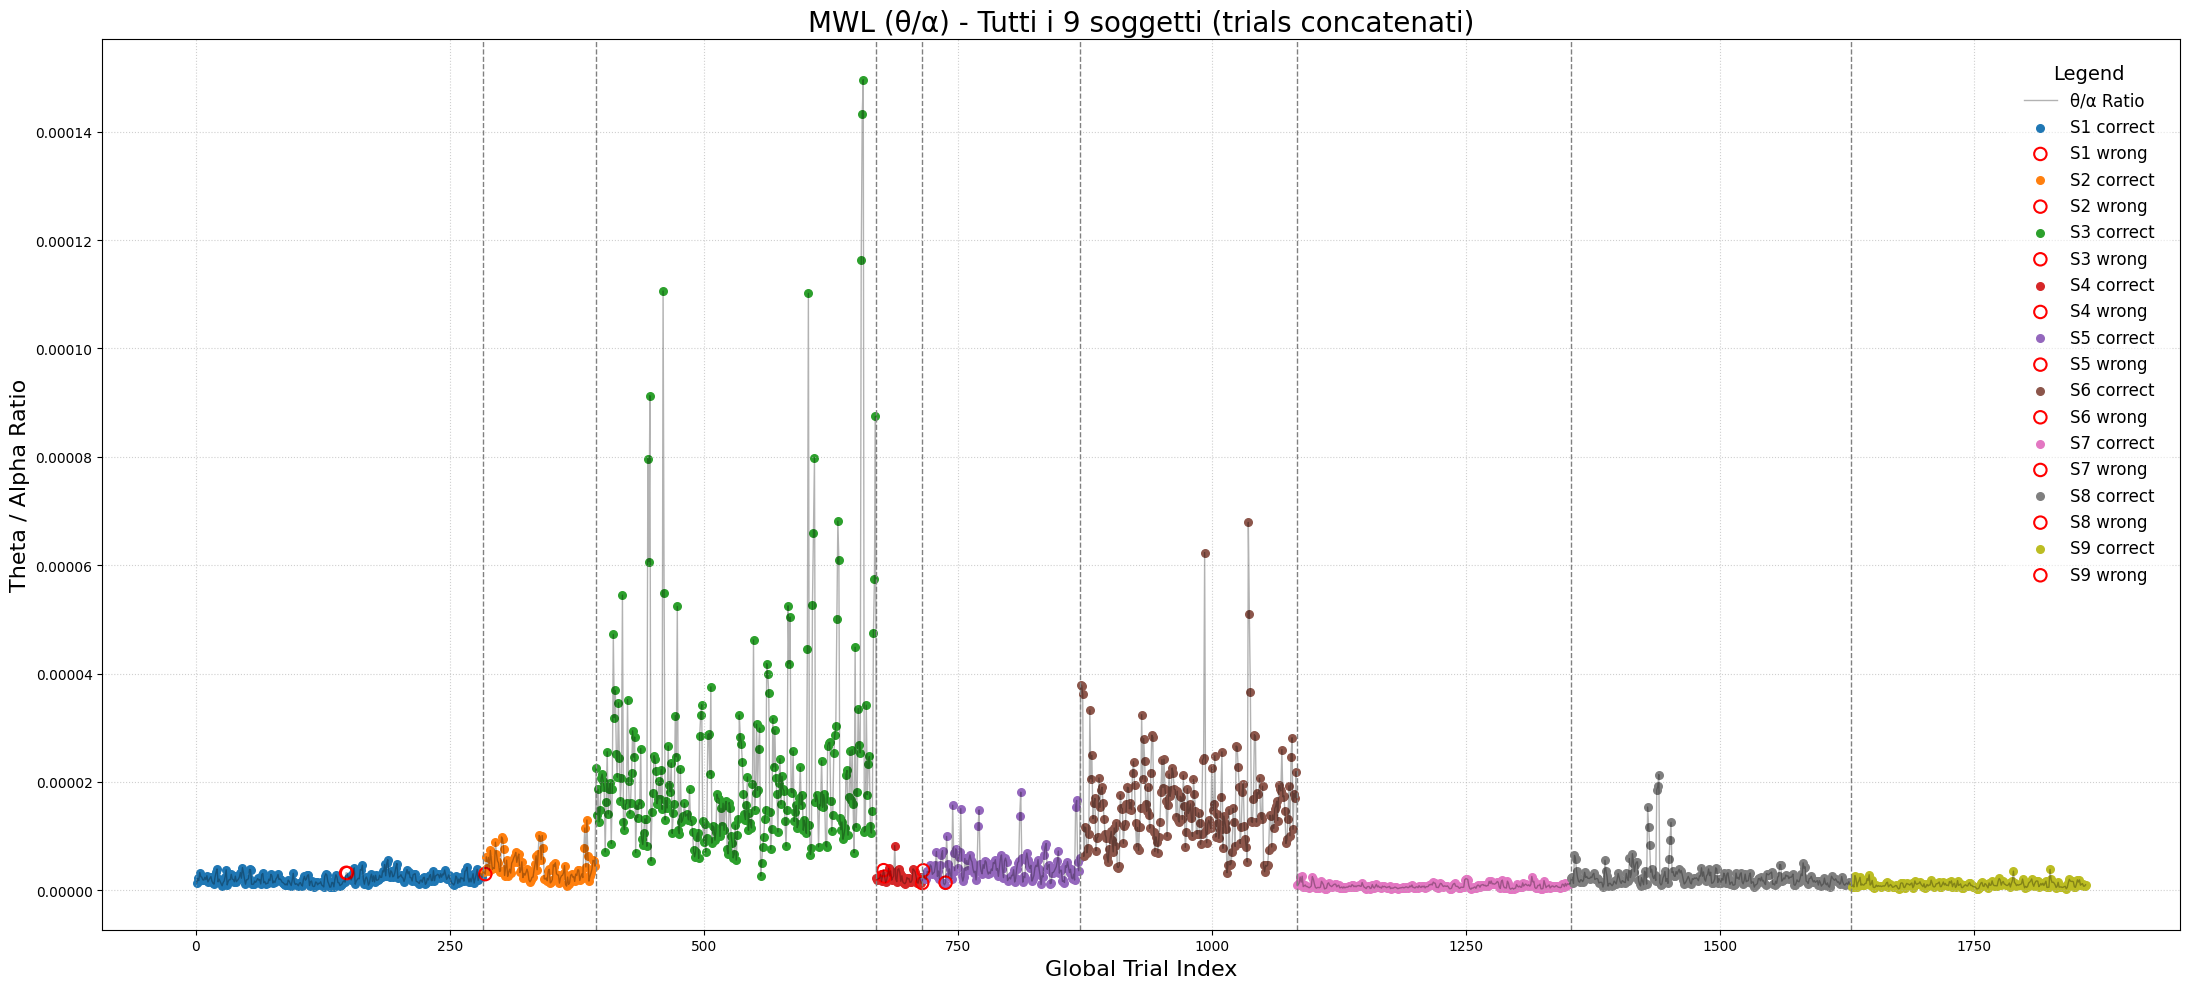

Grafico combinato salvato in 'mwl_combined_plot.png'


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ——— 1) Lettura e concatenazione dei CSV per ciascun soggetto ———
dfs = []
for sub in range(1, 10):
    df = pd.read_csv(f'B{sub}/bci2b_sub{sub}_combined.csv')
    df['subject'] = sub
    dfs.append(df)
combined = pd.concat(dfs, ignore_index=True)

# ——— 2) Calcolo dell’indice "global_trial" ———
combined = combined.sort_values(['subject','trial']).reset_index(drop=True)
counts = combined.groupby('subject').size().to_dict()
offset = {}
cum = 0
for sub in range(1,10):
    offset[sub] = cum
    cum += counts[sub]
combined['global_trial'] = combined.apply(
    lambda row: row['trial'] + offset[row['subject']], axis=1
)

# ——— 3) Prepara la figura ———
fig, ax = plt.subplots(figsize=(22, 10))

# 3a) Palette di colori
colors = plt.cm.tab10.colors
sub_colors = {sub: colors[(sub-1) % len(colors)] for sub in range(1,10)}

# 3b) Linea complessiva θ/α
ax.plot(combined['global_trial'], combined['theta_alpha'],
        color='black', linewidth=1, alpha=0.3, label='θ/α Ratio')

# 3c) Scatter per soggetto
for sub, grp in combined.groupby('subject'):
    correct = grp['pred_label'] == grp['true_label_x']
    # corretti: markers pieni colorati
    ax.scatter(grp.loc[correct,'global_trial'],
               grp.loc[correct,'theta_alpha'],
               color=sub_colors[sub], s=30, label=f'S{sub} correct')
    # errati: cerchi vuoti con bordo rosso
    ax.scatter(grp.loc[~correct,'global_trial'],
               grp.loc[~correct,'theta_alpha'],
               edgecolors='red', facecolors='none', s=80,
               linewidths=1.5, label=f'S{sub} wrong')

# ——— 4) Linee tratteggiate di separazione soggetto ———
boundaries = np.cumsum([counts[sub] for sub in range(1,10)])[:-1]
for b in boundaries:
    ax.axvline(x=b + 0.5, color='gray', linestyle='--', linewidth=1)

# ——— 5) Titoli, etichette e griglia ———
ax.set_title("MWL (θ/α) - Tutti i 9 soggetti (trials concatenati)", fontsize=20)
ax.set_xlabel("Global Trial Index", fontsize=16)
ax.set_ylabel("Theta / Alpha Ratio", fontsize=16)
ax.grid(True, linestyle=':', alpha=0.6)

# ——— 6) Legenda interna e compatta ———
handles, labels = ax.get_legend_handles_labels()
# Prendi solo la prima occorrenza
unique = dict(zip(labels, handles))
leg = ax.legend(unique.values(), unique.keys(),
                loc='upper right', fontsize=12,
                title="Legend", title_fontsize=14,
                framealpha=0.5, frameon=True,
                borderpad=1)
# Facoltativo: riquadro arrotondato
leg.get_frame().set_linewidth(0)

# ——— 7) Layout e salvataggio ———
plt.tight_layout()
plt.savefig('mwl_combined_plot.png', dpi=300)
plt.show()
print("Grafico combinato salvato in 'mwl_combined_plot.png'")  
